C:\Users\Usuario\Desktop\MC949\MC949-Visao-Computacional\venv310\lib\site-packages\torchvision\transforms\functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(
C:\Users\Usuario\Desktop\MC949\MC949-Visao-Computacional\venv310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Usuario\Desktop\MC949\MC949-Visao-Computacional\venv310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(ms

Reading from C:\Users\Usuario\Desktop\MC949\MC949-Visao-Computacional\data\T4


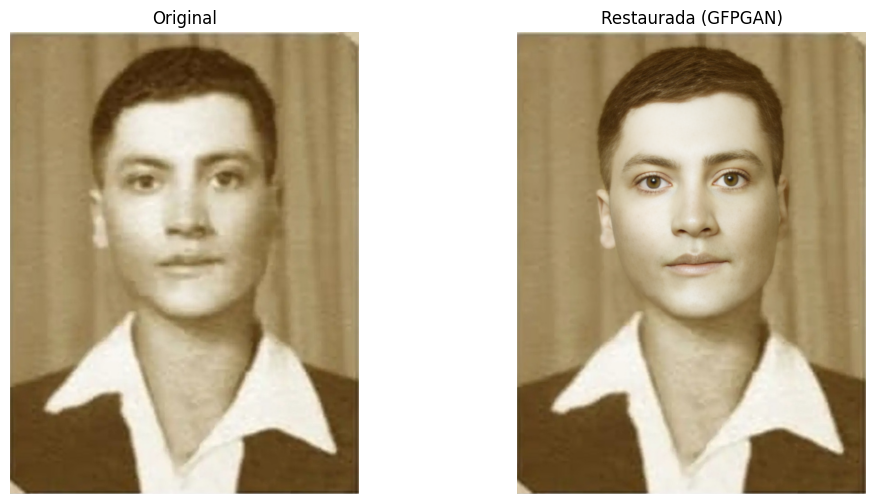

In [1]:
from gfpgan import GFPGANer
import cv2
from basicsr.utils.download_util import load_file_from_url
from canon.T4.utils import load_image_and_masks
import matplotlib.pyplot as plt

# --- Baixar automaticamente o modelo GFPGANv1.4 ---
model_url = "https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.4.pth"
model_path = load_file_from_url(url=model_url, model_dir=".", progress=True)

# --- Instanciar o modelo ---
restorer = GFPGANer(
    model_path=model_path,
    upscale=1,
    arch="clean",
    channel_multiplier=2,
    bg_upsampler=None
)

# --- Carrega a imagem antiga ---
img, masks = load_image_and_masks("antiga_1")

# GFPGAN espera imagem BGR → convertemos para RGB só depois
img_bgr = img

# --- Restaurar ---
cropped_faces, restored_faces, restored_img = restorer.enhance(
    img_bgr,
    has_aligned=False,
    only_center_face=False
)

# Converter para RGB para mostrar no matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
restored_rgb = cv2.cvtColor(restored_img, cv2.COLOR_BGR2RGB)

# --- Plot ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Restaurada (GFPGAN)")
plt.imshow(restored_rgb)
plt.axis('off')

plt.show()
